In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [2]:
df = pd.read_csv("C:/Users/hp/Downloads/Sentiment analysis for mental health/Combined Data.csv")

df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df.head()


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


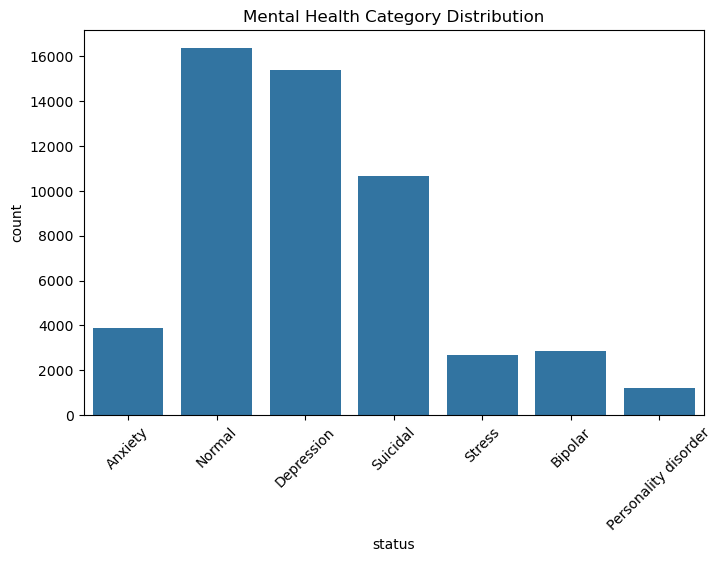

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x="status", data=df)
plt.title("Mental Health Category Distribution")
plt.xticks(rotation=45)
plt.show()

In [7]:
#Text Cleaning Function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'http\S+','',text)
    text = re.sub(r'[^a-zA-Z ]','',text)
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [9]:
#Convert Text to String(Ensures all text values are strings)
df["statement"] = df["statement"].astype(str)

In [10]:
df["clean_text"] = df["statement"].apply(clean_text)

df.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean


In [11]:
#Converts categorical labels into numbers
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["status"])

df.head()

,statement,status,clean_text,label
0,oh my gosh,Anxiety,oh gosh,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...,0
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted focus something else im still worried,0
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean,0


In [12]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Tokenization(Converts text into numerical sequences)
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [14]:
#Padding Sequences(Ensures all sequences have the same length)
max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [18]:
#Build RNN LSTM Model(Input → Embedding → LSTM → Dense → Output)
model = Sequential()
#Converts words into dense vector representations.
model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))

model.add(LSTM(128)) #Captures sequence patterns in text.

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu')) #Outputs probabilities for 5 classes.

model.add(Dense(len(df["label"].unique()), activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.build(input_shape=(None,100))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,295 (5.42 MB)

 Trainable params: 1,420,295 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#Train the Model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 54s 79ms/step - accuracy: 0.6372 - loss: 0.9175 - val_accuracy: 0.7226 - val_loss: 0.7208
Epoch 2/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.7557 - loss: 0.6380 - val_accuracy: 0.7542 - val_loss: 0.6528
Epoch 3/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.8060 - loss: 0.5153 - val_accuracy: 0.7679 - val_loss: 0.6237
Epoch 4/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.8349 - loss: 0.4394 - val_accuracy: 0.7561 - val_loss: 0.6805
Epoch 5/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 54s 81ms/step - accuracy: 0.8611 - loss: 0.3733 - val_accuracy: 0.7656 - val_loss: 0.6995
Epoch 6/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.8812 - loss: 0.3202 - val_accuracy: 0.7557 - val_loss: 0.7712
Epoch 7/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.8984 - loss: 0.2762 - val_accuracy: 0.7609 - val_loss: 0.7955
Epoch 8/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.9111 - loss: 0.2421 - 

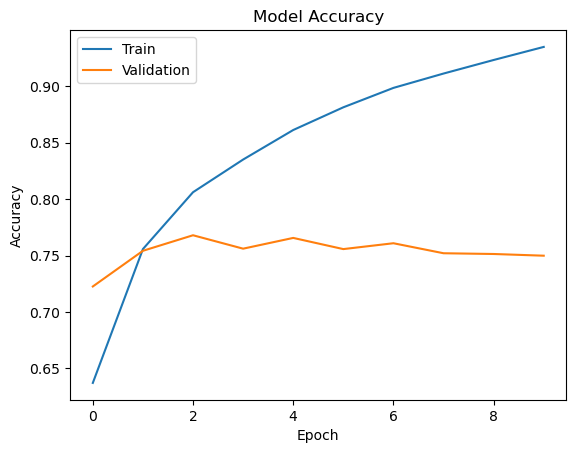

In [20]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [21]:
#Classification Report
pred = model.predict(X_test_pad)

pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

332/332 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
              precision    recall  f1-score   support

           0       0.82      0.72      0.77       779
           1       0.77      0.75      0.76       580
           2       0.73      0.66      0.69      3100
           3       0.93      0.91      0.92      3327
           4       0.63      0.56      0.60       248
           5       0.45      0.70      0.55       557
           6       0.61      0.68      0.64      2018

    accuracy                           0.75     10609
   macro avg       0.71      0.71      0.70     10609
weighted avg       0.76      0.75      0.75     10609



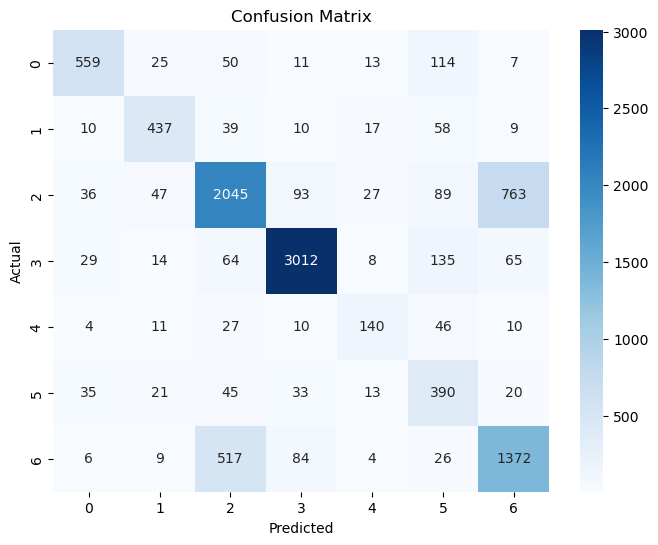

In [22]:
#Confusion matrix compares:Actual label vs Predicted label
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
#Prediction Function
#Creates a function to predict mental health condition from a new sentence
def predict_sentiment(text):

    text = clean_text(text)
    
    seq = tokenizer.texts_to_sequences([text])
    
    padded = pad_sequences(seq, maxlen=max_length)
    
    pred = model.predict(padded)
    
    label = np.argmax(pred)
    
    return encoder.inverse_transform([label])[0]

In [24]:
predict_sentiment("I feel very lonely and depressed today")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


'Depression'

In [25]:
model.save("mental_health_sentiment_rnn.h5")

In [26]:
import pickle

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))
pickle.dump(encoder, open("label_encoder.pkl", "wb"))